# Getting Data From Github:

In [21]:
!git clone https://github.com/laxmimerit/dog-cat-full-dataset.git

Cloning into 'dog-cat-full-dataset'...
remote: Enumerating objects: 25027, done.
remote: Total 25027 (delta 0), reused 0 (delta 0), pack-reused 25027
Receiving objects: 100% (25027/25027), 541.62 MiB | 37.01 MiB/s, done.
Resolving deltas: 100% (5/5), done.
Updating files: 100% (25001/25001), done.


# Turning On Mixed Precision Training:

In [20]:
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy(policy= "mixed_float16")

# Importing Necessary Libraries:

In [60]:
import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, MaxPool2D, Conv2D, Input, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Importing and Viewing Data:

In [27]:
data_dir = "/content/dog-cat-full-dataset/data"

In [28]:
os.listdir(data_dir)

['train', 'test']

In [30]:
# training and Test Data Directories:
train_dir = data_dir+"/train/"
test_dir = data_dir+"/test/"

In [31]:
os.listdir(train_dir)

['dogs', 'cats']

In [32]:
os.listdir(test_dir)

['dogs', 'cats']

In [33]:
# Checking Files and Folders in Data Directory:
for dirpath, dirnames, filenames in os.walk(data_dir):
    print(f"There are {len(filenames)} files and {len(dirnames)} folders in Directory {dirpath}")

There are 0 files and 2 folders in Directory /content/dog-cat-full-dataset/data
There are 0 files and 2 folders in Directory /content/dog-cat-full-dataset/data/train
There are 10000 files and 0 folders in Directory /content/dog-cat-full-dataset/data/train/dogs
There are 10000 files and 0 folders in Directory /content/dog-cat-full-dataset/data/train/cats
There are 0 files and 2 folders in Directory /content/dog-cat-full-dataset/data/test
There are 2500 files and 0 folders in Directory /content/dog-cat-full-dataset/data/test/dogs
There are 2500 files and 0 folders in Directory /content/dog-cat-full-dataset/data/test/cats


## Visualizing Random Images:

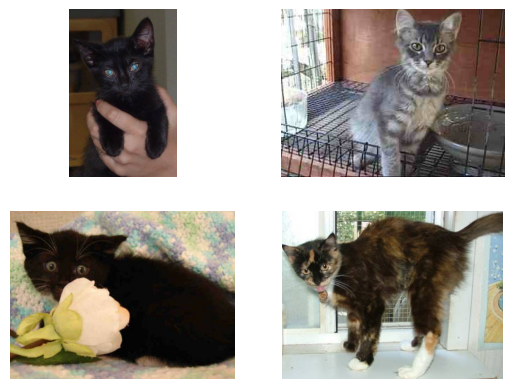

In [34]:
class_names = ["cats", "dogs"]

random_class = random.choice(class_names)

for i in range(4):

    random_image = random.choice(os.listdir(train_dir+"/"+random_class))
    plt.subplot(2,2,i+1)
    plt.imshow(plt.imread(train_dir+"/"+random_class+"/"+random_image))
    plt.axis(False)

# Image Data Generators:

In [35]:
train_datagen = ImageDataGenerator(rescale= 1/255)
test_datagen = ImageDataGenerator(rescale= 1/255)

In [61]:
# Creating Data Flows from Training and Test Data::
train_data = train_datagen.flow_from_directory(directory= train_dir,
                                              target_size= (224,224),
                                              color_mode= "rgb",
                                              class_mode= "binary",
                                              batch_size= 32)

test_data = test_datagen.flow_from_directory(directory= test_dir,
                                            target_size= (224,224),
                                            color_mode= "rgb",
                                            class_mode= "binary",
                                            batch_size= 32,
                                            shuffle= False)

Found 20000 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.


# Creating, Compiling and Fitting Model:

In [63]:
# Creating The Model:

model1 = Sequential()

model1.add(Input(shape= (224,224,3)))

model1.add(Conv2D(filters= 132, kernel_size= 5, activation= "relu"))
model1.add(MaxPool2D(pool_size= 2))

model1.add(Conv2D(filters= 64, kernel_size= 5, activation= "relu"))
model1.add(MaxPool2D(pool_size= 2))

model1.add(Conv2D(filters= 32, kernel_size= 5, activation= "relu"))
model1.add(MaxPool2D(pool_size= 2))

model1.add(Dense(132, activation= "relu"))

model1.add(Dense(64, activation= "relu"))

model1.add(Flatten())

model1.add(Dense(1, activation= "sigmoid"))

# Compiling The Model:

model1.compile(optimizer= Adam(),
             loss= BinaryCrossentropy(),
             metrics= ["accuracy"])

# Fitting The Model:
history_1 = model1.fit(train_data,
                      epochs= 50,
                      validation_data= test_data,
                      callbacks= EarlyStopping(monitor= "val_loss",
                                              patience= 3))

Epoch 1/50
625/625 [==============================] - 126s 197ms/step - loss: 0.6852 - accuracy: 0.5515 - val_loss: 0.6748 - val_accuracy: 0.5940
Epoch 2/50
625/625 [==============================] - 121s 193ms/step - loss: 0.6480 - accuracy: 0.6276 - val_loss: 0.6276 - val_accuracy: 0.6570
Epoch 3/50
625/625 [==============================] - 121s 194ms/step - loss: 0.5934 - accuracy: 0.6872 - val_loss: 0.5582 - val_accuracy: 0.7250
Epoch 4/50
625/625 [==============================] - 122s 194ms/step - loss: 0.5130 - accuracy: 0.7536 - val_loss: 0.5026 - val_accuracy: 0.7634
Epoch 5/50
625/625 [==============================] - 122s 195ms/step - loss: 0.4639 - accuracy: 0.7803 - val_loss: 0.5187 - val_accuracy: 0.7580
Epoch 6/50
625/625 [==============================] - 131s 209ms/step - loss: 0.4164 - accuracy: 0.8115 - val_loss: 0.4486 - val_accuracy: 0.7940
Epoch 7/50
625/625 [==============================] - 123s 196ms/step - loss: 0.3731 - accuracy: 0.8314 - val_loss: 0.4457 -

# Model Loss and Accuracy Curves:

In [64]:
# Evaluationg Model on Full Test Data:
model1.evaluate(test_data)

157/157 [==============================] - 13s 80ms/step - loss: 0.5415 - accuracy: 0.8004


[0.541450023651123, 0.8004000186920166]

In [69]:
history_1.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

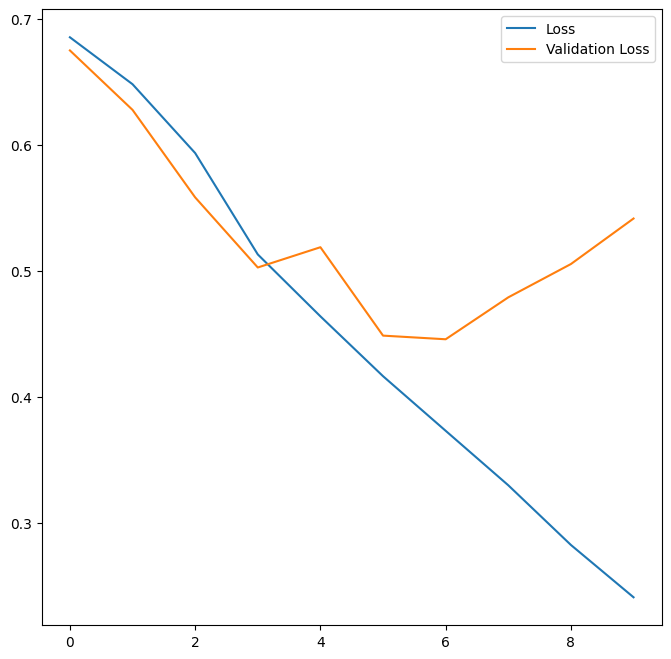

In [70]:
plt.figure(figsize= (8,8))
plt.plot(history_1.history["loss"], label= "Loss")
plt.plot(history_1.history["val_loss"], label= "Validation Loss")
plt.legend()
plt.show()

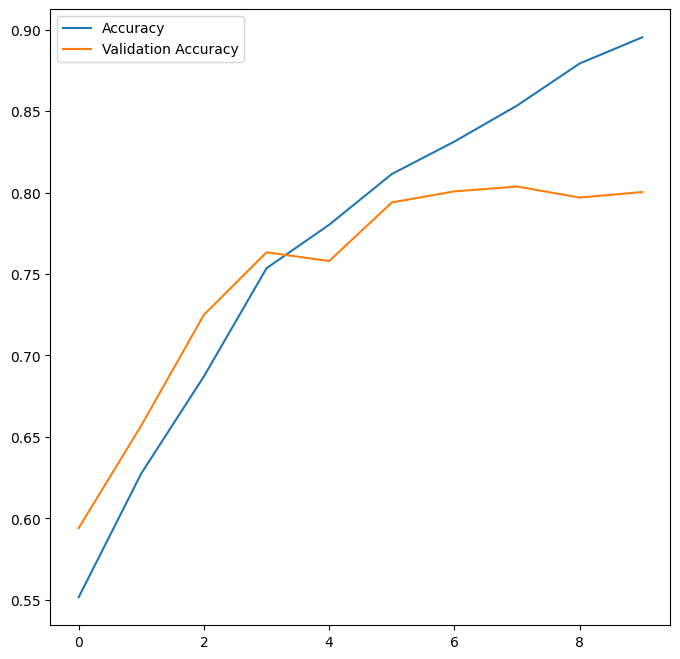

In [71]:
plt.figure(figsize= (8,8))
plt.plot(history_1.history["accuracy"], label= "Accuracy")
plt.plot(history_1.history["val_accuracy"], label= "Validation Accuracy")
plt.legend()
plt.show()

# Prediction and Model Evaluation:

In [72]:
model_pred_probs = model1.predict(test_data)
model_pred_probs

157/157 [==============================] - 14s 89ms/step


array([[0.06793 ],
       [0.3267  ],
       [0.3396  ],
       ...,
       [0.975   ],
       [0.978   ],
       [0.001597]], dtype=float16)

In [73]:
model_preds = tf.round(model_pred_probs)
model_preds

<tf.Tensor: shape=(5000, 1), dtype=float16, numpy=
array([[0.],
       [0.],
       [0.],
       ...,
       [1.],
       [1.],
       [0.]], dtype=float16)>

In [74]:
test_data.classes.shape, model_preds.shape

((5000,), TensorShape([5000, 1]))

In [75]:
print(classification_report(test_data.classes, tf.squeeze(model_preds)))

              precision    recall  f1-score   support

           0       0.79      0.82      0.80      2500
           1       0.81      0.79      0.80      2500

    accuracy                           0.80      5000
   macro avg       0.80      0.80      0.80      5000
weighted avg       0.80      0.80      0.80      5000



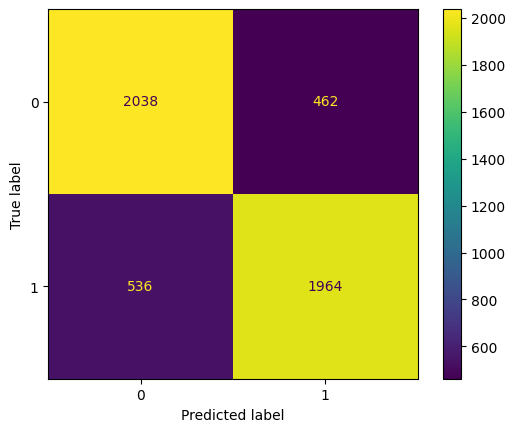

In [76]:
cm = confusion_matrix(test_data.classes, tf.squeeze(model_preds))
disp = ConfusionMatrixDisplay(cm)
disp.plot()